In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import lime
import lime.lime_tabular
import warnings

df = pd.read_csv("../data/cleaned/final_prepared_dataset.csv")
df.head()

,name,GW,total_points,minutes,goals_scored,assists,bonus,bps,clean_sheets,creativity,...,team_x_Newcastle,team_x_Norwich,team_x_Nott'm Forest,team_x_Sheffield Utd,team_x_Southampton,team_x_Spurs,team_x_Watford,team_x_West Brom,team_x_West Ham,team_x_Wolves
0,Aaron Connolly,1,1,45,0,0,0,-3,0,0.3,...,False,False,False,False,False,False,False,False,False,False
1,Aaron Connolly,2,8,89,1,0,2,27,1,11.3,...,False,False,False,False,False,False,False,False,False,False
2,Aaron Connolly,3,2,73,0,0,0,2,0,12.1,...,False,False,False,False,False,False,False,False,False,False
3,Aaron Connolly,4,2,65,0,0,0,7,0,0.3,...,False,False,False,False,False,False,False,False,False,False
4,Aaron Connolly,5,4,12,0,1,0,13,0,10.3,...,False,False,False,False,False,False,False,False,False,False


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv("../data/cleaned/final_prepared_dataset.csv")

# Split features & target
X = df.drop(columns=["name", "GW", "upcoming_total_points"])
y = df["upcoming_total_points"]

# Train / Test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# Initialize model
model = LinearRegression()
model.fit(X_train, y_train)

# --- Validation performance ---
y_val_pred = model.predict(X_val)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

# --- Test performance ---
y_test_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Validation Metrics:")
print(f"  MAE: {val_mae:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  R²: {val_r2:.4f}\n")

print("Test Metrics:")
print(f"  MAE: {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²: {test_r2:.4f}")


Validation Metrics:
  MAE: 1.4013
  RMSE: 2.3435
  R²: 0.2937

Test Metrics:
  MAE: 1.3611
  RMSE: 2.2900
  R²: 0.3069


Explaining 400 randomly sampled test samples...


  0%|          | 0/400 [00:00<?, ?it/s]

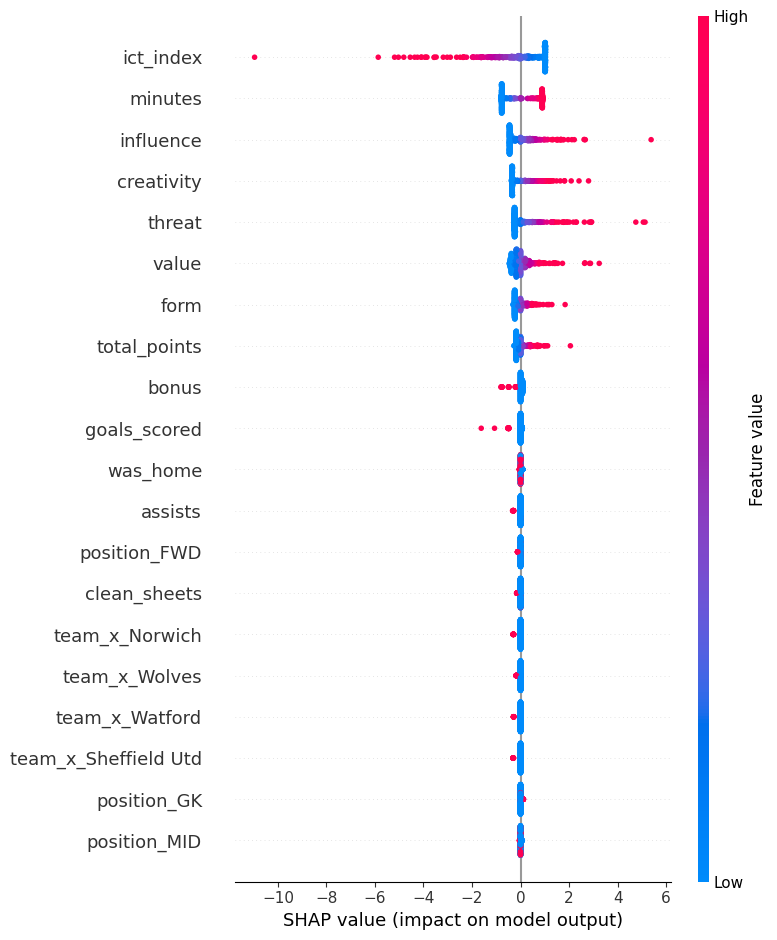

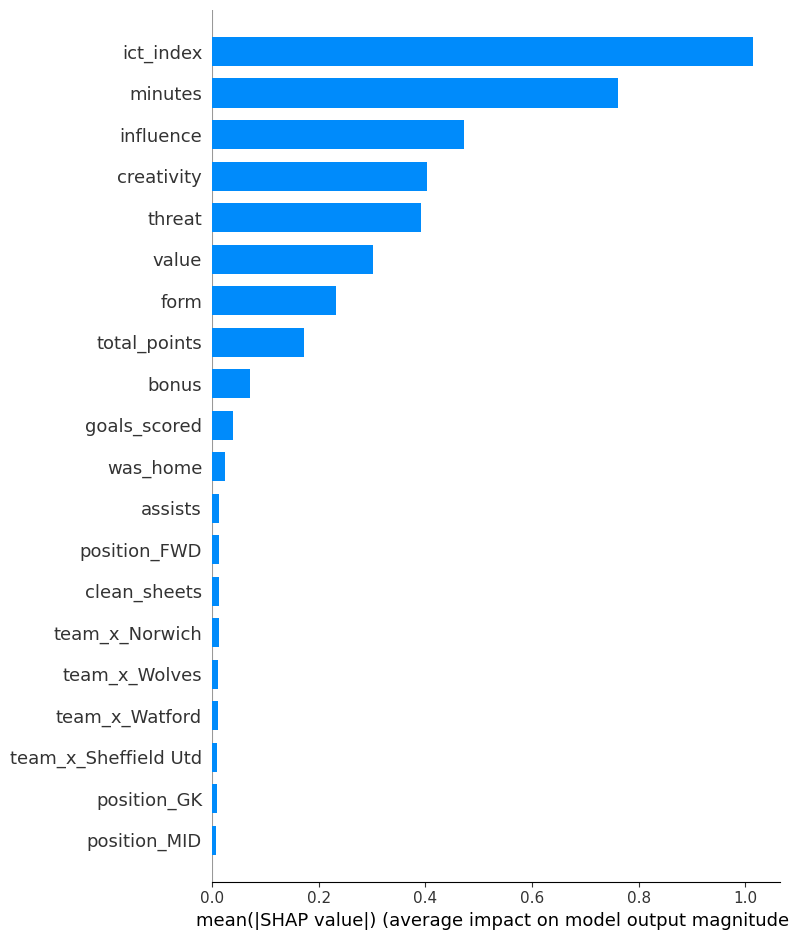


Top 15 Most Important Features (by SHAP values):
           feature  importance
10       ict_index    1.014019
1          minutes    0.762013
8        influence    0.473339
7       creativity    0.403498
9           threat    0.391815
12           value    0.301323
11            form    0.233218
0     total_points    0.171768
4            bonus    0.072217
2     goals_scored    0.039324
13        was_home    0.025121
3          assists    0.013663
16    position_FWD    0.012699
6     clean_sheets    0.012674
34  team_x_Norwich    0.012585


In [6]:

warnings.filterwarnings('ignore')

# Use KernelExplainer which is more stable
def predict_fn(X):
    return model.predict(X)

# Use smaller background sample for efficiency
background = X_train.sample(n=100, random_state=42)
explainer = shap.KernelExplainer(predict_fn, background)

# Use random sample of 400 test samples instead of all
sample_size = 400
X_test_sample = X_test.sample(n=sample_size, random_state=42)

print(f"Explaining {len(X_test_sample)} randomly sampled test samples...")
shap_values = explainer.shap_values(X_test_sample)

# Summary plot with sampled data
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

# Additional plots with sampled data
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", feature_names=X.columns)

# Show feature importance
feature_importance = np.mean(np.abs(shap_values), axis=0)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features (by SHAP values):")
print(importance_df.head(15))

LIME explanations for 400 random test samples:

Generating LIME feature importance across 400 samples...

Top 15 Features (LIME average importance):
           feature  avg_importance
10       ict_index        1.297263
1          minutes        0.789753
9           threat        0.651207
8        influence        0.609493
7       creativity        0.527211
12           value        0.459721
11            form        0.293899
0     total_points        0.270127
4            bonus        0.157210
2     goals_scored        0.141970
3          assists        0.077295
6     clean_sheets        0.060019
39  team_x_Watford        0.057867
13        was_home        0.055139
34  team_x_Norwich        0.050887


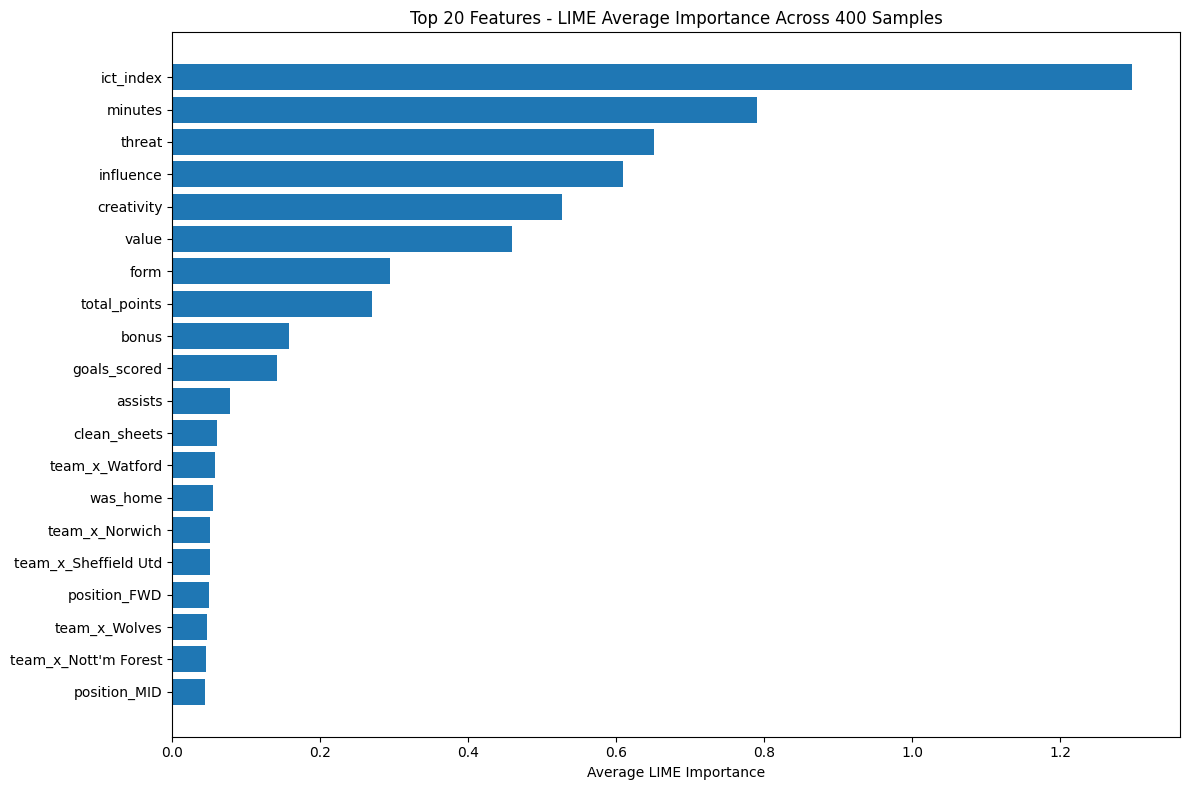

In [7]:

# LIME explanation for regression - Fixed version
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=list(X.columns),  # Ensure proper list format
    mode='regression',
    discretize_continuous=False,  # Turn off discretization to match feature names
    random_state=42
)

# Explain a sample of 400 predictions with LIME
sample_size = 400
X_test_sample = X_test.sample(n=sample_size, random_state=42)

print(f"LIME explanations for {sample_size} random test samples:")

import matplotlib.pyplot as plt

# Get feature importance across all 400 samples
print(f"\nGenerating LIME feature importance across {sample_size} samples...")
lime_importances = []

for i in range(sample_size):
    exp = explainer_lime.explain_instance(
        X_test_sample.values[i],
        model.predict,
        num_features=len(X.columns)
    )
    # Extract feature importance from explanation
    feature_weights = dict(exp.as_list())
    lime_importances.append(feature_weights)

# Calculate average importance across all samples
avg_importance = {}
for feature in X.columns:
    weights = [imp.get(feature, 0) for imp in lime_importances]
    avg_importance[feature] = np.mean(np.abs(weights))

# Display top features
lime_importance_df = pd.DataFrame({
    'feature': list(avg_importance.keys()),
    'avg_importance': list(avg_importance.values())
}).sort_values('avg_importance', ascending=False)

print("\nTop 15 Features (LIME average importance):")
print(lime_importance_df.head(15))

# Plot overall LIME feature importance
plt.figure(figsize=(12, 8))
top_20_lime = lime_importance_df.head(20)
plt.barh(range(len(top_20_lime)), top_20_lime['avg_importance'])
plt.yticks(range(len(top_20_lime)), top_20_lime['feature'])
plt.xlabel('Average LIME Importance')
plt.title('Top 20 Features - LIME Average Importance Across 400 Samples')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
